In [18]:
# Ncessary import for graphs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx

In [19]:
# Read nodes and edges from CSV files

nodes_df = pd.read_csv('nodes.csv')
edges_df = pd.read_csv('edges.csv')



In [20]:
nodes_df.head()

,Id,Label
0,5097316,ROSE
1,5098095,JACK
2,5097875,CAL
3,5098619,MOLLY
4,5098545,SMITH


In [21]:
nodes_df.shape # We have 70 nodes.

(70, 2)

In [22]:
edges_df.head()

,Source,Target,Weight
0,5096932,5096969,1
1,5098606,5103789,1
2,5098606,5098095,1
3,5098606,5101061,1
4,5098606,5097941,1


In [23]:
edges_df['Weight'].describe()

count    299.000000
mean       1.481605
std        1.431488
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       19.000000
Name: Weight, dtype: float64

In [24]:
# Check whether each of the source and target in edges_df exists in nodes_df
missing_sources = set(edges_df['Source']) - set(nodes_df['Id'])
missing_targets = set(edges_df['Target']) - set(nodes_df['Id'])



Every element of the source and the target is member of the ID from the nodes_df

In [25]:
# Create a graph and add nodes from nodes_df, then add edges and their weights from edges_df
G = nx.Graph()
# Add nodes with attributes
for _, row in nodes_df.iterrows():
    G.add_node(row['Id'], label=row['Label'], group=row['Label']) 
# Add edges with weights
for _, row in edges_df.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

# Print basic graph information
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")


Number of nodes: 70
Number of edges: 299


In [26]:
# Print the edges with their weights
for u, v, data in G.edges(data=True):
    # Print the source, target, and weight of each edge in the format "Source -> Target (Weight)" and also print the labels of the source and target nodes
    # order by the weight of the edge in descending order
    print(f"{G.nodes[u]['label']} ({u}) -> {G.nodes[v]['label']} ({v}) (Weight: {data['weight']})")

    

ROSE (5097316) -> BODINE (5096948) (Weight: 4)
ROSE (5097316) -> BUELL (5097212) (Weight: 1)
ROSE (5097316) -> CAL (5097875) (Weight: 8)
ROSE (5097316) -> CNN REPORTER (5097296) (Weight: 1)
ROSE (5097316) -> COLONEL GRACIE (5099110) (Weight: 1)
ROSE (5097316) -> FABRIZIO (5098128) (Weight: 2)
ROSE (5097316) -> GENTLEMAN (5102317) (Weight: 1)
ROSE (5097316) -> GUGGENHEIM (5100327) (Weight: 1)
ROSE (5097316) -> HELGA (5099499) (Weight: 1)
ROSE (5097316) -> HUSBAND (5104295) (Weight: 1)
ROSE (5097316) -> HUTCHINSON (5102267) (Weight: 1)
ROSE (5097316) -> JOUGHIN (5105104) (Weight: 1)
ROSE (5097316) -> LIGHTOLLER (5101061) (Weight: 2)
ROSE (5097316) -> LIZZY (5097505) (Weight: 4)
ROSE (5097316) -> LOVEJOY (5097941) (Weight: 3)
ROSE (5097316) -> MAN (5097994) (Weight: 3)
ROSE (5097316) -> MARVIN (5099903) (Weight: 1)
ROSE (5097316) -> OLD ROSE (5098041) (Weight: 5)
ROSE (5097316) -> OPERATOR (5103330) (Weight: 1)
ROSE (5097316) -> ANDREWS (5098606) (Weight: 4)
ROSE (5097316) -> BROCK (50993

In [31]:
print(G.nodes(data=True))

[(5097316, {'label': 'ROSE', 'group': 'ROSE'}), (5098095, {'label': 'JACK', 'group': 'JACK'}), (5097875, {'label': 'CAL', 'group': 'CAL'}), (5098619, {'label': 'MOLLY', 'group': 'MOLLY'}), (5098545, {'label': 'SMITH', 'group': 'SMITH'}), (5101061, {'label': 'LIGHTOLLER', 'group': 'LIGHTOLLER'}), (5096969, {'label': 'LOVETT', 'group': 'LOVETT'}), (5097941, {'label': 'LOVEJOY', 'group': 'LOVEJOY'}), (5098606, {'label': 'ANDREWS', 'group': 'ANDREWS'}), (5097894, {'label': 'RUTH', 'group': 'RUTH'}), (5098041, {'label': 'OLD ROSE', 'group': 'OLD ROSE'}), (5096948, {'label': 'BODINE', 'group': 'BODINE'}), (5098128, {'label': 'FABRIZIO', 'group': 'FABRIZIO'}), (5098463, {'label': 'WOMAN', 'group': 'WOMAN'}), (5098583, {'label': 'ISMAY', 'group': 'ISMAY'}), (5101981, {'label': 'MURDOCH', 'group': 'MURDOCH'}), (5100134, {'label': 'STEWARD', 'group': 'STEWARD'}), (5097212, {'label': 'BUELL', 'group': 'BUELL'}), (5101285, {'label': 'FLEET', 'group': 'FLEET'}), (5101840, {'label': 'LEE', 'group': 

In [34]:
! pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


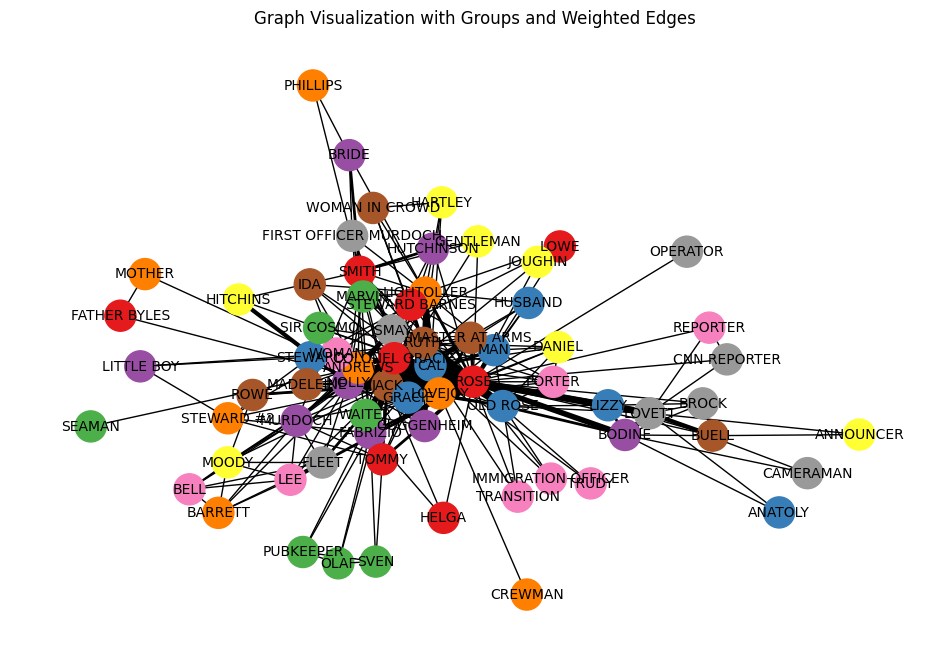

In [37]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

# Convert group names to numeric color ids
groups = list(set(nx.get_node_attributes(G, 'group').values()))
group_map = {group: i for i, group in enumerate(groups)}

node_colors = [group_map[G.nodes[node]['group']] for node in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.Set1,
    node_size=500
)

# Edge widths
edge_weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_weights)

# Labels
labels = {node: G.nodes[node]['label'] for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=10)

plt.title("Graph Visualization with Groups and Weighted Edges")
plt.axis('off')
plt.show()